# **1. Business Understanding**

## E-Commerce Data Analysis (Olist)

## Business Problem

Olist is a Brazilian e-commerce platform with multiple sellers.

This project aims to analyze sales performance, customer behavior,
product performance, and delivery efficiency.

## Business Questions

1. What is the total revenue trend over time?
2. Which products sell the most?
3. Which cities have the highest revenue?
4. How is the product price distributed?
5. Does delivery time affect the review score?
6. Which payment method is used most often?

# **2. Data Understanding**

## Import Library

In [148]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Connect Database

In [149]:
conn = sqlite3.connect('olist.sqlite')

cursor = conn.cursor()

## Inspect Data

In [150]:
df_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(df_tables)

                                 name
0   product_category_name_translation
1                             sellers
2                           customers
3                         geolocation
4                         order_items
5                      order_payments
6                       order_reviews
7                              orders
8                            products
9                     leads_qualified
10                       leads_closed


# **3. Data Preparation**

create dataset with join

In [151]:
query = """
SELECT
o.order_id,
o.order_purchase_timestamp,
c.customer_state,
oi.product_id,
oi.price,
p.product_category_name,
pay.payment_type,
o_r.review_score

FROM orders o

JOIN customers c
ON o.customer_id = c.customer_id

JOIN order_items oi
ON o.order_id = oi.order_id

JOIN products p
ON oi.product_id = p.product_id

JOIN order_payments pay
ON o.order_id = pay.order_id

JOIN order_reviews o_r
ON o.order_id = o_r.order_id
"""

df = pd.read_sql(query, conn)
df.head(3)

,order_id,order_purchase_timestamp,customer_state,product_id,price,product_category_name,payment_type,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,SP,87285b34884572647811a353c7ac498a,29.99,utilidades_domesticas,credit_card,4
1,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,SP,87285b34884572647811a353c7ac498a,29.99,utilidades_domesticas,voucher,4
2,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,SP,87285b34884572647811a353c7ac498a,29.99,utilidades_domesticas,voucher,4


# **4. Data Cleaning**

* missing values
* duplicate
* data type

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117329 entries, 0 to 117328
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  117329 non-null  object 
 1   order_purchase_timestamp  117329 non-null  object 
 2   customer_state            117329 non-null  object 
 3   product_id                117329 non-null  object 
 4   price                     117329 non-null  float64
 5   product_category_name     115634 non-null  object 
 6   payment_type              117329 non-null  object 
 7   review_score              117329 non-null  int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 7.2+ MB


In [153]:
df.isnull().sum()

order_id                       0
order_purchase_timestamp       0
customer_state                 0
product_id                     0
price                          0
product_category_name       1695
payment_type                   0
review_score                   0
dtype: int64

handle missing values

In [154]:
df["product_category_name"] = df["product_category_name"].fillna("Unknown")

In [155]:
df.isnull().sum()

order_id                    0
order_purchase_timestamp    0
customer_state              0
product_id                  0
price                       0
product_category_name       0
payment_type                0
review_score                0
dtype: int64

change datatype

In [156]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

create new columns (year, month)

In [157]:
df["year"] = df["order_purchase_timestamp"].dt.year
df["month"] = df["order_purchase_timestamp"].dt.month

# **5. EDA** 

# 1. What is the total revenue trend over time?

**per year**

In [180]:
query = """
SELECT 
    strftime('%Y', o.order_purchase_timestamp) AS year,
    SUM(oi.price) AS total_revenue
FROM orders o 
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY year
ORDER BY year DESC;
"""

df_seller_revenue = pd.read_sql_query(query, conn)
df_seller_revenue.head()

,year,total_revenue
0,2018,7.386051e+06
1,2017,6.155807e+06
2,2016,4.978592e+04


**per month**

In [159]:
query = """
SELECT 
    strftime('%M', o.order_purchase_timestamp) AS month,
    SUM(oi.price) AS total_revenue
FROM orders o 
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY month
ORDER BY month DESC
LIMIT 12;
"""

df_seller_revenue = pd.read_sql_query(query, conn)
df_seller_revenue.head()

,month,total_revenue
0,59,220248.64
1,58,244536.62
2,57,235549.74
3,56,220928.45
4,55,216801.41


# 2. Which products sell the most?

In [160]:
query = """
SELECT 
    p.product_category_name,
    SUM(oi.order_item_id) AS quantity
FROM products p
JOIN order_items oi ON p.product_id = oi.product_id
GROUP BY p.product_category_name
ORDER BY quantity DESC;
"""

best_seller_product = pd.read_sql_query(query, conn)
best_seller_product.head(3)

,product_category_name,quantity
0,cama_mesa_banho,13665
1,moveis_decoracao,11540
2,beleza_saude,11081


# 3. Which cities have the highest revenue?

In [161]:
query = """
SELECT 
    c.customer_city,
    SUM(oi.price) AS total_revenue
FROM orders o 
JOIN order_items oi ON o.order_id = oi.order_id
JOIN customers c ON c.customer_id = o.customer_id
GROUP BY c.customer_city
ORDER BY total_revenue DESC;
"""

df_city_revenue = pd.read_sql_query(query, conn)
df_city_revenue.head()

,customer_city,total_revenue
0,sao paulo,1914924.54
1,rio de janeiro,992538.86
2,belo horizonte,355611.13
3,brasilia,301920.25
4,curitiba,211738.06


# 4. How is the product price distributed?

In [162]:
q = """SELECT 
        product_id,
        price,
        (price / order_item_id) AS price_per_product
        FROM order_items
        """

df_price_distribution = pd.read_sql_query(q, conn)
df_price_distribution.head()

,product_id,price,price_per_product
0,4244733e06e7ecb4970a6e2683c13e61,58.90,58.90
1,e5f2d52b802189ee658865ca93d83a8f,239.90,239.90
2,c777355d18b72b67abbeef9df44fd0fd,199.00,199.00
3,7634da152a4610f1595efa32f14722fc,12.99,12.99
4,ac6c3623068f30de03045865e4e10089,199.90,199.90


In [163]:
q = """SELECT
        AVG(price)
        FROM order_items
        """

avg_price = pd.read_sql_query(q, conn)
avg_price.head()

,AVG(price)
0,120.653739


# 5. Does delivery time affect the review score?

In [164]:
query = """
SELECT o.order_id,
        o.order_delivered_customer_date,
        o.order_delivered_carrier_date,
        o_r.review_score
FROM orders o 
JOIN order_reviews o_r ON o.order_id = o_r.order_id
order by o_r.review_score DESC;
"""

df_rating = pd.read_sql_query(query, conn)

# 1. Pastikan kolom menjadi format datetime
df_rating['order_delivered_customer_date'] = pd.to_datetime(df_rating['order_delivered_customer_date'])
df_rating['order_delivered_carrier_date'] = pd.to_datetime(df_rating['order_delivered_carrier_date'])

# 2. Hitung selisihnya (dalam satuan hari)
df_rating['delivery_time_days'] = (df_rating['order_delivered_customer_date'] - df_rating['order_delivered_carrier_date']).dt.days

# 3. Cek hasilnya
print(df_rating[['order_delivered_carrier_date', 'order_delivered_customer_date', 'delivery_time_days']].head())

  order_delivered_carrier_date order_delivered_customer_date  \
0          2018-08-08 13:50:00           2018-08-17 18:06:29   
1          2017-11-22 13:39:59           2017-12-02 00:28:42   
2          2018-02-14 19:46:34           2018-02-16 18:17:02   
3          2017-05-22 10:07:46           2017-05-26 12:55:51   
4          2017-08-10 19:45:24           2017-08-16 17:14:30   

   delivery_time_days  
0                 9.0  
1                 9.0  
2                 1.0  
3                 4.0  
4                 5.0  


# 6. Which payment method is used most often?

In [165]:
query = """
SELECT payment_type,
        COUNT(payment_type) AS jumlah_transaksi
FROM order_payments
GROUP BY payment_type
ORDER BY jumlah_transaksi DESC;
"""

df_payment_method = pd.read_sql_query(query, conn)
df_payment_method

,payment_type,jumlah_transaksi
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


# **6. Visualization**

## 1. Trend Revenue Per Year & Month

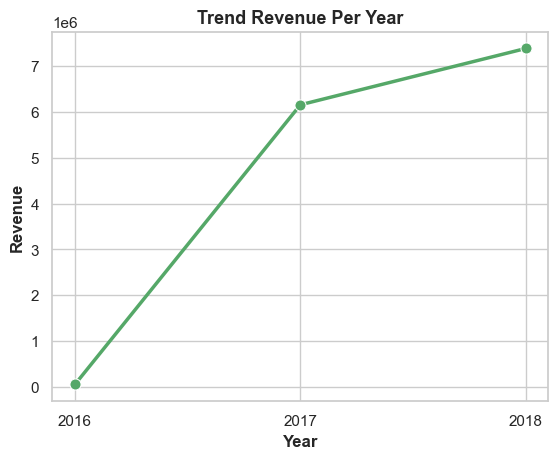

In [185]:
sns.set_theme(style="whitegrid")

trend_revenue_per_year = df_seller_revenue.sort_values(by='year', ascending=True)

sns.lineplot(data=trend_revenue_per_year,
             x='year',
             y='total_revenue',
             marker='o',
             markersize=8,
             linewidth=2.5,
             color='g')

plt.title('Trend Revenue Per Year', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Revenue', fontsize=12, fontweight='bold')

plt.show()

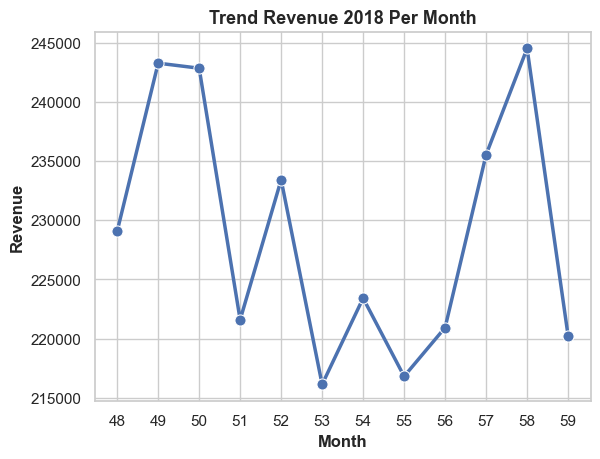

In [178]:
sns.set_theme(style="whitegrid")

trend_revenue_per_month = df_seller_revenue.sort_values(by='month', ascending=True)

sns.lineplot(data=trend_revenue_per_month,
             x='month',
             y='total_revenue',
             marker='o',
             markersize=8,
             linewidth=2.5,
             color='b')

plt.title('Trend Revenue 2018 Per Month', fontsize=13, fontweight='bold')
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Revenue', fontsize=12, fontweight='bold')

plt.show()

# 2. Top Seller Product

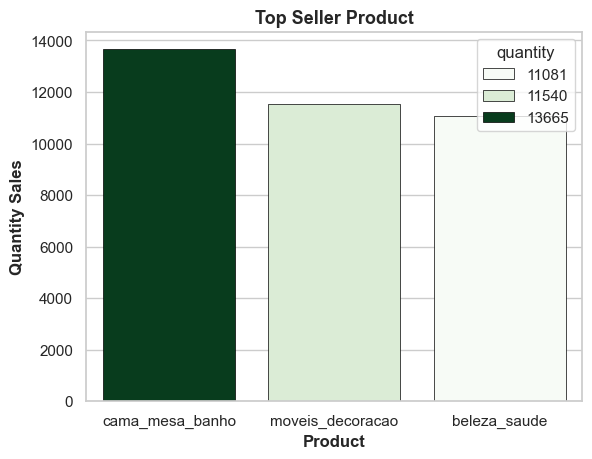

In [239]:
sns.set_theme(style="whitegrid")

top_3 = best_seller_product.sort_values(by='quantity', ascending=False).head(3)

sns.barplot(data=top_3,
            x='product_category_name',
            y='quantity', 
            hue='quantity',
            palette='Greens',
            edgecolor='black',
            linewidth=0.5)

plt.title('Top Seller Product', fontsize=13, fontweight='bold')
plt.xlabel('Product', fontsize=12, fontweight='bold')
plt.ylabel('Quantity Sales', fontsize=12, fontweight='bold')

plt.show()

# 3. Top City Revenue

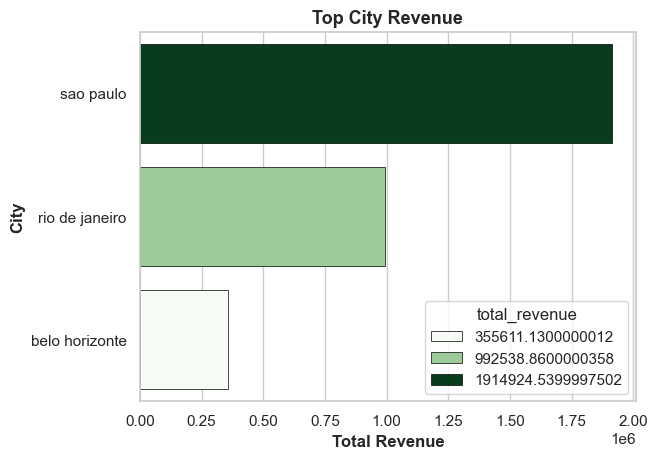

In [240]:
sns.set_theme(style="whitegrid")

top_city = df_city_revenue.sort_values(by='total_revenue', ascending=False).head(3)

sns.barplot(data=top_city,
            x='total_revenue',
            y='customer_city',
            orient='h',  # -> horizontal
            hue='total_revenue',
            palette='Greens',
            edgecolor='black',
            linewidth=0.5)

plt.title('Top City Revenue', fontsize=13, fontweight='bold')
plt.xlabel('Total Revenue', fontsize=12, fontweight='bold')
plt.ylabel('City', fontsize=12, fontweight='bold')

plt.show()

# 4. Product Price Distribution

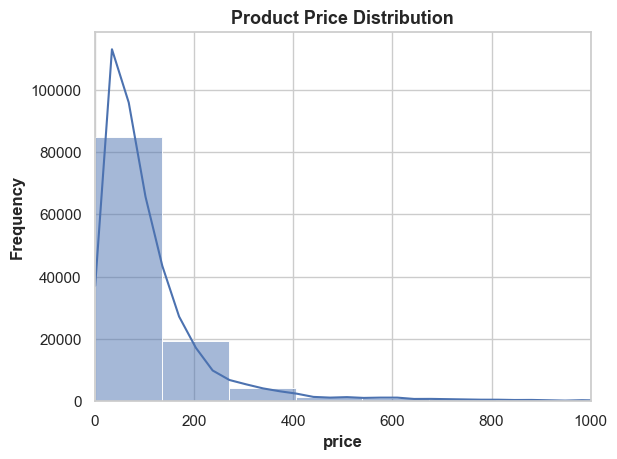

In [244]:
sns.set_theme(style="whitegrid")

sns.histplot(data=df_price_distribution['price'],
             bins=50,
             kde=True,)

plt.xlim(0, 1000) # -> dibatasi sampai 1000

plt.title('Product Price Distribution', fontsize=13, fontweight='bold')
plt.xlabel('price', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')

plt.show()

# 5. Corellation Delivery Time and Review Score

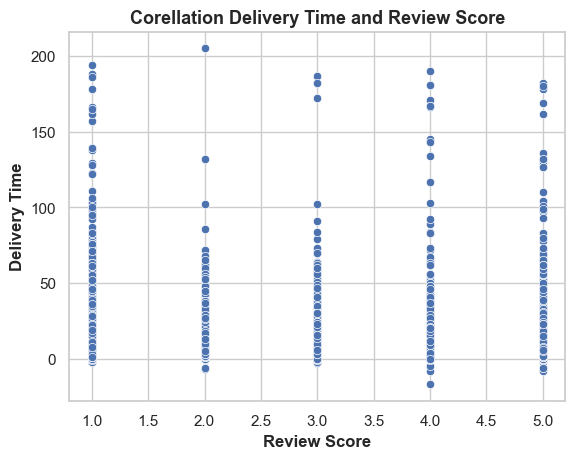

In [227]:
sns.set_theme(style="whitegrid")

sns.scatterplot(data=df_rating,
                y='delivery_time_days',
                x='review_score')

plt.title('Corellation Delivery Time and Review Score', fontsize=13, fontweight='bold')
plt.xlabel('Review Score', fontsize=12, fontweight='bold')
plt.ylabel('Delivery Time', fontsize=12, fontweight='bold')

plt.show()

# 6. Payment Method Distribution

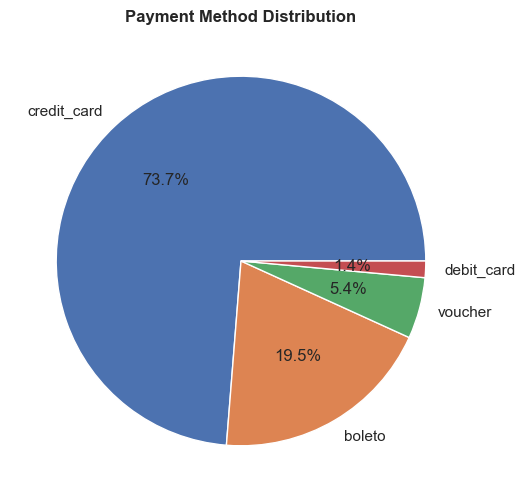

In [204]:
payment_counts = df["payment_type"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(payment_counts, labels=payment_counts.index, autopct="%1.1f%%")

plt.title("Payment Method Distribution", fontsize=12, fontweight='bold')
plt.show()

# **7. Insights**

1. Revenue trends have been increasing annually, with the highest increase occurring in 2018. The peak occurred at the end of the year, from September to December.
2. Top 3 products: cama_mesa_banho, moveis_decoracao, beleza_saude.
3. Top 3 cities: ao paulo, rio de janeiro, belo horizonte.
4. Many products are priced below 1000, with an average of 120.653739.
5. There is no strong linear correlation between delivery and review score.
6. 73.8% of payments are made using credit cards.

## **8. Recommendation**

1. Optimize the end-of-year period from September to December, create promotions, and increase quantities.
2. Increase stock of best-selling products.
3. Increase stock and promotions at stores in the best cities.
4. Prices are good and quite competitive.
5. Delivery time does not affect customer review scores. This means it's not an issue and other issues can be prioritized.
6. Offer promotions if customers make payments.